In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
# Load the dataset
file_path = '../../data/Data3.csv'  # Make sure the file is in the same directory as the code
data = pd.read_csv(file_path)
# Create a 'Site' column with the first 7 letters of the 'ERBS' column
data['Site'] = data['ERBS'].str[:7]

# Group by 'Site' and 'STARTTIME_DATE', then average the values
grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()

C:\Users\HP\AppData\Local\Temp\ipykernel_135156\1075902420.py:8: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()


In [3]:
# Normalize the target columns between 0 and 10
scaler = MinMaxScaler(feature_range=(0, 10))
columns_to_normalize = ['AVG_USR_THRPUT_DL', 'AVG_NO_USER', 'DL_TRAFFIC_MB']
grouped_data[columns_to_normalize] = scaler.fit_transform(grouped_data[columns_to_normalize])


In [5]:
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

In [7]:
# Load and prepare the data
file_path = '../../data/Data3.csv'  # Update with your actual file path
data = pd.read_csv(file_path)
data['Site'] = data['ERBS'].str[:7]
data['STARTTIME_DATE'] = pd.to_datetime(data['STARTTIME_DATE'])
grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()

C:\Users\HP\AppData\Local\Temp\ipykernel_135156\1081723962.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()


In [8]:
# Define the create_sequences function
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Function to calculate MSE for each site
def calculate_mse_for_sites(target_column):
    mse_results = {}
    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values
        site_data = site_data.reshape(-1, 1)
        
        if len(site_data) <= 10:
            continue
        
        X, y = create_sequences(site_data, seq_length=10)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Define and train the LSTM model
        model = Sequential()
        model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(0.2))
        model.add(LSTM(50, return_sequences=False))
        model.add(Dropout(0.2))
        model.add(Dense(1))
        
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.2, verbose=0)
        
        # Predict and calculate MSE
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        
        mse_results[site] = mse
    
    return mse_results

# Calculate MSE for DL_TRAFFIC_MB
mse_results_dl_traffic = calculate_mse_for_sites('DL_TRAFFIC_MB')

# Sort results and get the best and worst 5 sites
sorted_mse_results = sorted(mse_results_dl_traffic.items(), key=lambda x: x[1])
best_5_sites = sorted_mse_results[:5]
worst_5_sites = sorted_mse_results[-5:]

print("Best 5 Sites based on MSE:", best_5_sites)
print("Worst 5 Sites based on MSE:", worst_5_sites)

# Initialize the dictionary to store predictions
site_predictions_dl_traffic = {}

# Train the model for each site
for site, _ in best_5_sites + worst_5_sites:
    site_data = grouped_data[grouped_data['Site'] == site][target_column].values
    site_data = site_data.reshape(-1, 1)

    seq_length = 10
    if len(site_data) <= seq_length:
        continue
    
    X, y = create_sequences(site_data, seq_length)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Define the LSTM model
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.2, verbose=0)
    
    # Store the predictions for plotting and analysis
    y_pred = model.predict(X_test)
    site_predictions_dl_traffic[site] = (X_test, y_test, y_pred)

# Function to plot actual vs. predicted for DL_TRAFFIC_MB
def plot_actual_vs_predicted_dl_traffic(site, y_test, y_pred):
    plt.figure(figsize=(10, 5))
    plt.plot(y_test, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Actual vs Predicted for DL_TRAFFIC_MB - Site: {site}')
    plt.xlabel('Time Steps')
    plt.ylabel('DL_TRAFFIC_MB')
    plt.legend()
    plt.show()

# Plot for the best and worst 5 sites for DL_TRAFFIC_MB
for site, _ in best_5_sites + worst_5_sites:
    _, y_test, y_pred = site_predictions_dl_traffic[site]
    plot_actual_vs_predicted_dl_traffic(site, y_test, y_pred)

3/3 [==============================] - 2s 9ms/step


3/3 [==============================] - 1s 7ms/step
Best 5 Sites based on MSE: [('BMBNC49', 427821977.1338975), ('BMBNC55', 530595030.74155277), ('BMKSB57', 575347572.7625382), ('BMBNC48', 627377726.1640869), ('BMKSB55', 627953802.7770954)]
Worst 5 Sites based on MSE: [('CXUKH40', 36609434650.4455), ('CXUKH38', 39068632951.80181), ('CXUKH64', 39703925250.954216), ('CXUKH39', 43663601672.794174), ('CXUKH62', 54986356630.91061)]


NameError: name 'target_column' is not defined

In [9]:
# Set the target column for DL_TRAFFIC_MB
target_column = 'DL_TRAFFIC_MB'

# Initialize the dictionary to store predictions
site_predictions_dl_traffic = {}

# Train the model for each site
for site, _ in best_5_sites + worst_5_sites:
    site_data = grouped_data[grouped_data['Site'] == site][target_column].values
    site_data = site_data.reshape(-1, 1)

    seq_length = 10
    if len(site_data) <= seq_length:
        continue
    
    X, y = create_sequences(site_data, seq_length)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Define the LSTM model
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.2, verbose=0)
    
    # Store the predictions for plotting and analysis
    y_pred = model.predict(X_test)
    site_predictions_dl_traffic[site] = (X_test, y_test, y_pred)

# Function to plot actual vs. predicted for DL_TRAFFIC_MB
def plot_actual_vs_predicted_dl_traffic(site, y_test, y_pred):
    plt.figure(figsize=(10, 5))
    plt.plot(y_test, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Actual vs Predicted for DL_TRAFFIC_MB - Site: {site}')
    plt.xlabel('Time Steps')
    plt.ylabel('DL_TRAFFIC_MB')
    plt.legend()
    plt.show()

# Plot for the best and worst 5 sites for DL_TRAFFIC_MB
for site, _ in best_5_sites + worst_5_sites:
    _, y_test, y_pred = site_predictions_dl_traffic[site]
    plot_actual_vs_predicted_dl_traffic(site, y_test, y_pred)

3/3 [==============================] - 1s 5ms/step


NameError: name 'plt' is not defined

In [10]:
# Plot for the best 5 sites
for site, _ in best_5_sites:
    if site in site_predictions_no_user:
        y_test, y_pred = site_predictions_no_user[site]
        plot_actual_vs_predicted(site, y_test, y_pred)
    else:
        print(f"Site {site} not found in site_predictions_no_user.")

# Plot for the worst 5 sites
for site, _ in worst_5_sites:
    if site in site_predictions_no_user:
        y_test, y_pred = site_predictions_no_user[site]
        plot_actual_vs_predicted(site, y_test, y_pred)
    else:
        print(f"Site {site} not found in site_predictions_no_user.")

NameError: name 'site_predictions_no_user' is not defined

3/3 [==============================] - 2s 0s/step


3/3 [==============================] - 1s 0s/step
Best 5 Sites based on MSE: [('BMBNC49', 427882986.7444495), ('BMBNC55', 530501415.9667028), ('BMKSB57', 575379731.7518662), ('BMBNC48', 627384204.1862999), ('BMKSB55', 627936933.7412711)]
Worst 5 Sites based on MSE: [('CXUKH40', 36609385667.02314), ('CXUKH38', 39068418070.50607), ('CXUKH64', 39703943781.18499), ('CXUKH39', 43664179923.297066), ('CXUKH62', 54986338595.52935)]


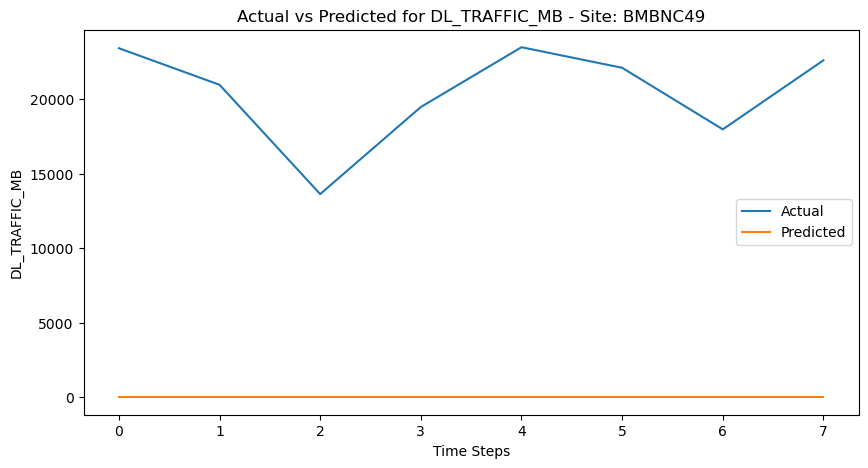

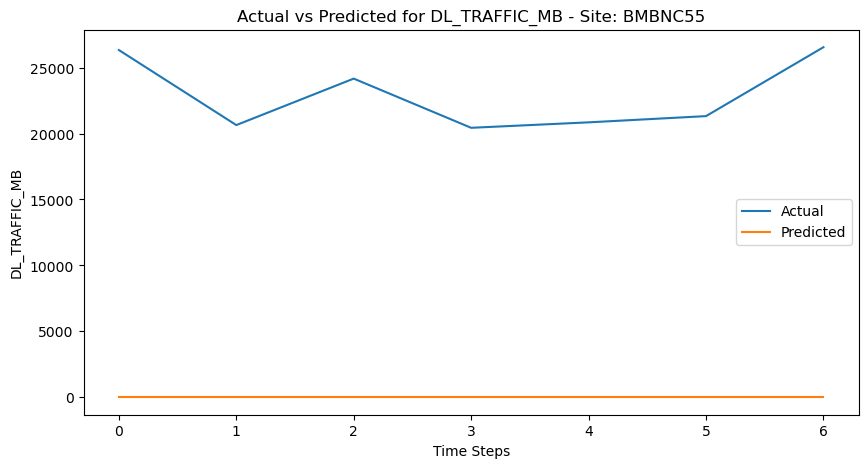

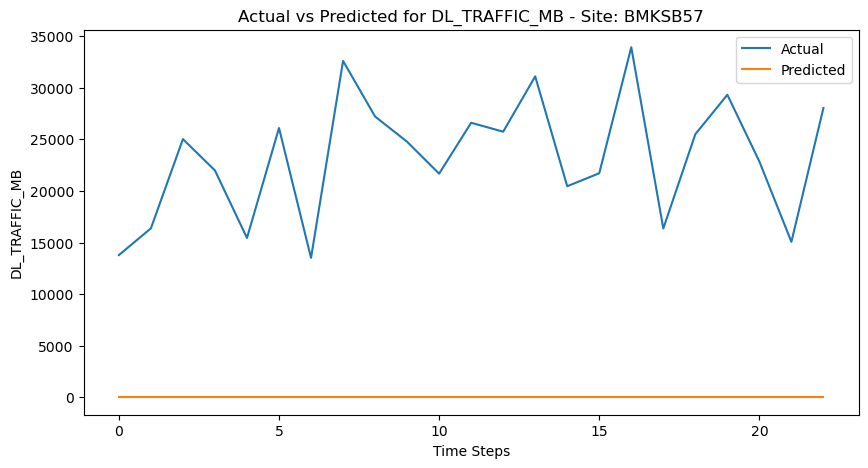

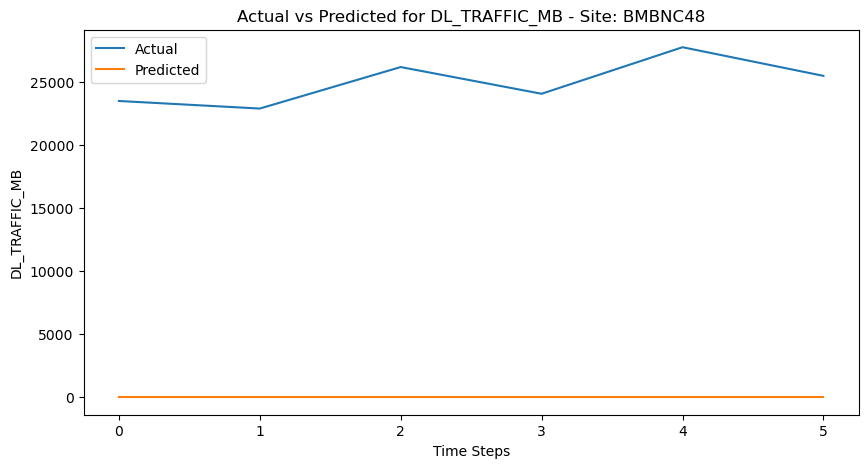

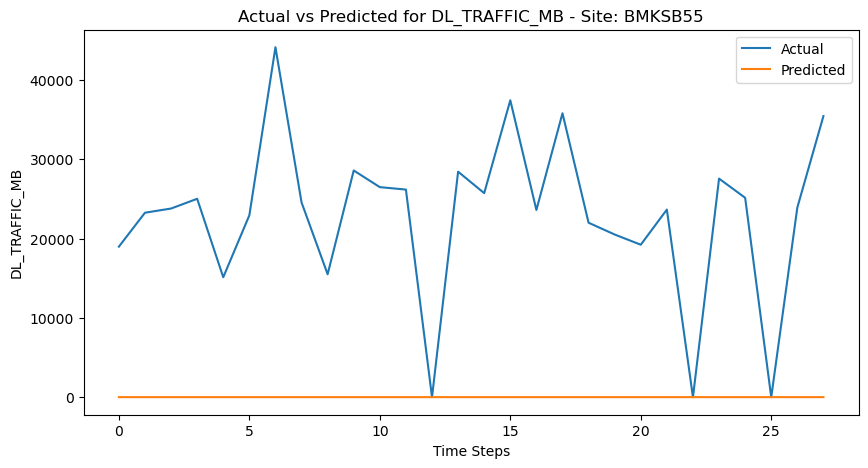

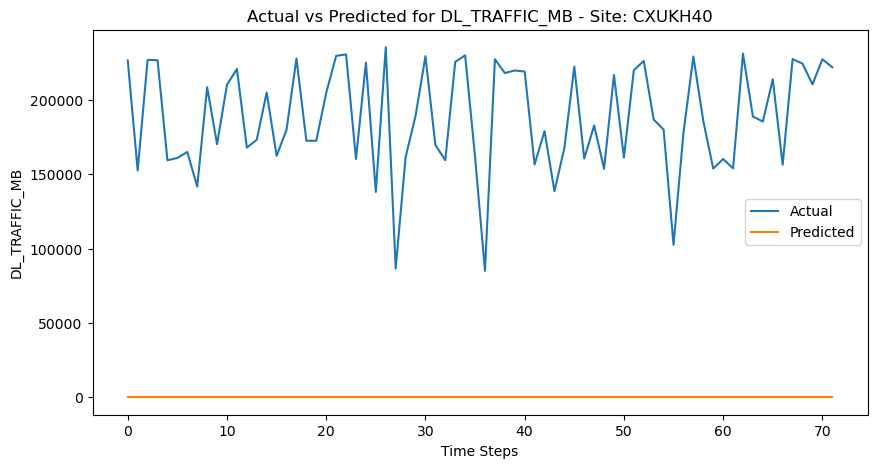

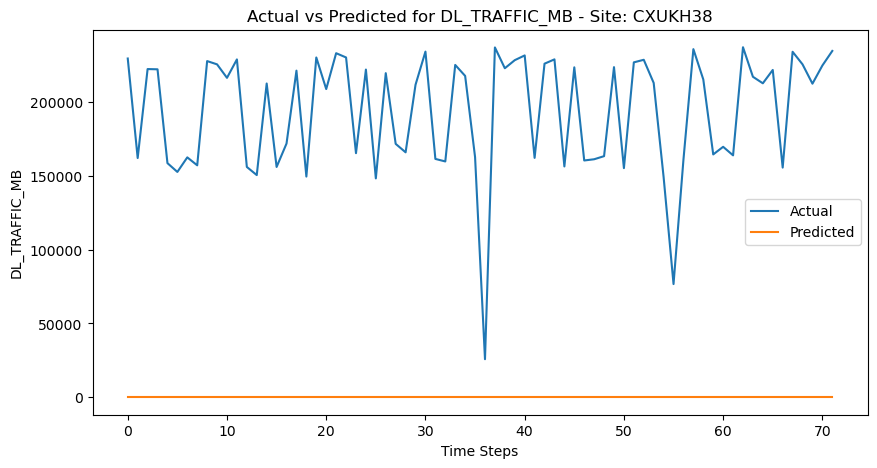

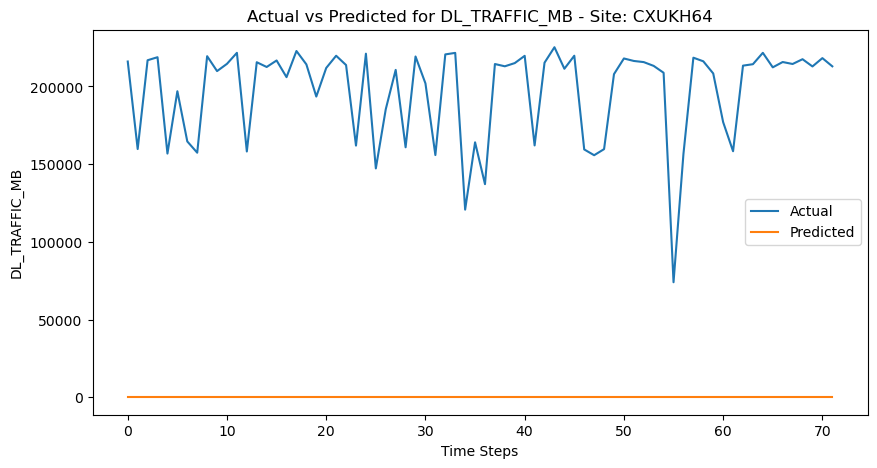

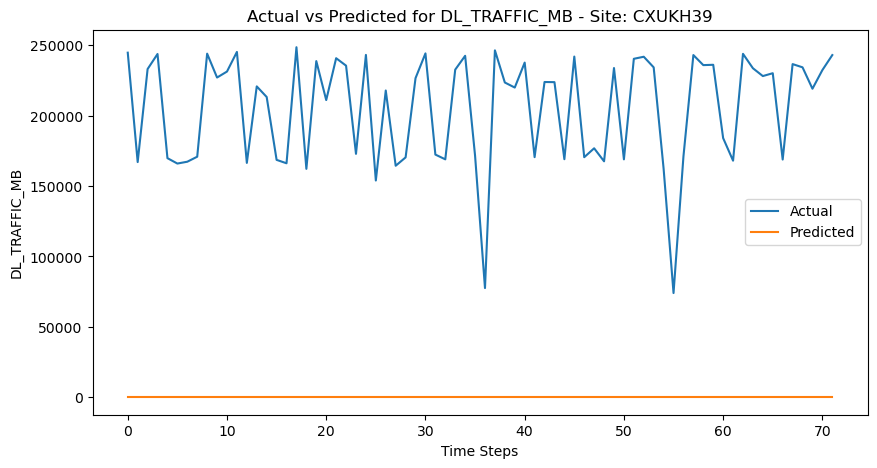

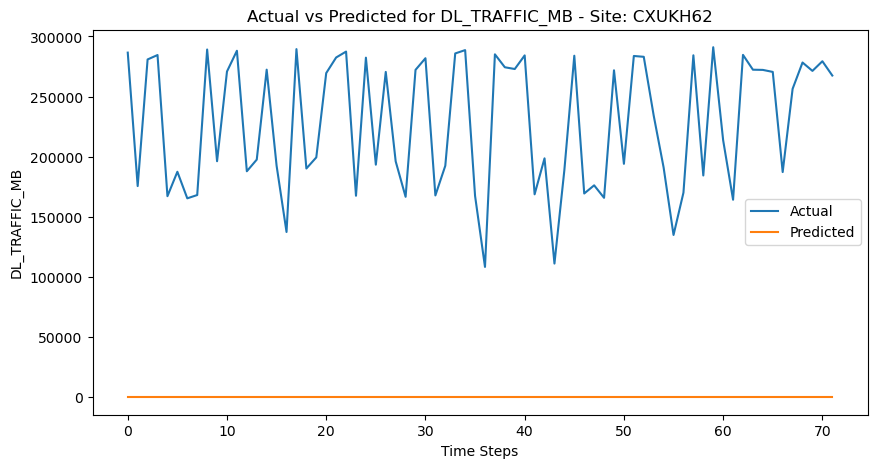

In [13]:
# Function to calculate MSE for each site and store predictions
def calculate_mse_and_predictions_for_sites(target_column, seq_length=10):
    mse_results = {}
    site_predictions = {}
    
    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values
        site_data = site_data.reshape(-1, 1)
        
        if len(site_data) <= seq_length:
            continue
        
        X, y = create_sequences(site_data, seq_length)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Define and train the LSTM model
        model = Sequential()
        model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(0.2))
        model.add(LSTM(50, return_sequences=False))
        model.add(Dropout(0.2))
        model.add(Dense(1))
        
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.2, verbose=0)
        
        # Predict and calculate MSE
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        
        mse_results[site] = mse
        site_predictions[site] = (y_test, y_pred)
    
    return mse_results, site_predictions

# Calculate MSE and get predictions for DL_TRAFFIC_MB
mse_results_dl_traffic, site_predictions_dl_traffic = calculate_mse_and_predictions_for_sites('DL_TRAFFIC_MB')

# Sort results and get the best and worst 5 sites
sorted_mse_results = sorted(mse_results_dl_traffic.items(), key=lambda x: x[1])
best_5_sites = sorted_mse_results[:5]
worst_5_sites = sorted_mse_results[-5:]

print("Best 5 Sites based on MSE:", best_5_sites)
print("Worst 5 Sites based on MSE:", worst_5_sites)

# Function to plot actual vs. predicted for DL_TRAFFIC_MB
def plot_actual_vs_predicted_dl_traffic(site, y_test, y_pred):
    plt.figure(figsize=(10, 5))
    plt.plot(y_test, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Actual vs Predicted for DL_TRAFFIC_MB - Site: {site}')
    plt.xlabel('Time Steps')
    plt.ylabel('DL_TRAFFIC_MB')
    plt.legend()
    plt.show()

# Plot for the best and worst 5 sites for DL_TRAFFIC_MB
for site, _ in best_5_sites + worst_5_sites:
    y_test, y_pred = site_predictions_dl_traffic[site]
    plot_actual_vs_predicted_dl_traffic(site, y_test, y_pred)